# **FinancialAnalysis of Customer Data using SQL & Python in BigQuery **



To build this financial use case, we are using **BigQuery Public Datasets**,  thelook_ecommerce dataset available.

We are going to create customer_profile.csv from public data and store it into Google Cloud Storage bucket.

Navigate to Cloud Shell and run following queries for intial cloud storage bucket creation:

$gcloud auth list

$gcloud config list

$gcloud storage buckets create gs://your-project-name-demo --location=region

*Note: Replace your-project-name & region as per your project configurations*

# Step 1: Enable Gemini in BigQuery Studio
Before starting, ensure participants know how to activate the AI assistant.

Look at the top right corner of the BigQuery Studio Notebook interface.

Ensure the Gemini icon (the sparkle logo) is active, or use the in-cell code generation tool by clicking the chat icon inside an empty cell.

For Python code generation, they can also use inline prompts by typing # or clicking "Generate Code" directly in a code cell.

Step 2: Extracting the "GCS Dataset" (Simulating the Lab Setup)
To make your lab realistic, you want participants to load customer profiles from GCS and transactions from BigQuery. We can split thelook_ecommerce to achieve this.

Run this SQL query in BigQuery to look at the user profiles, then export it to a GCS bucket to simulate your first lab component.
Run this Query in BigQuery Studio and save the result in *"Your_Bucket"* (created in above step) as ***customer.csv***

-- Query to inspect the customer profiles
SELECT
    id AS customer_id,
    age,
    gender,
    country,
    traffic_source
FROM
    `bigquery-public-data.thelook_ecommerce.users`;

In [ ]:
# sql_engine: bigquery
# output_variable: df
# output_mode: table
# start _sql
_sql = """
SELECT
    id AS customer_id,
    age,
    gender,
    country,
    traffic_source
FROM
    `bigquery-public-data.thelook_ecommerce.users`;
""" # end _sql
from google.colab.sql import bigquery as _bqsqlcell
df = _bqsqlcell.run(_sql)
df

,customer_id,age,gender,country,traffic_source
0,25000,12,M,Japan,Search
1,48633,12,F,United States,Facebook
2,48646,12,F,United States,Search
3,91149,12,F,United States,Search
4,72127,12,F,United States,Display
5,95074,12,F,United States,Search
6,8519,12,M,Brasil,Search
7,74916,12,F,Brasil,Email
8,18189,12,F,Brasil,Search
9,26255,12,M,Brasil,Search


# Step 1: Environmental Setup & Authentication
Part A: Load the Customer Profiles from GCS
Participants pull the demographic data from GCS using Pandas.

In [ ]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.cloud import bigquery
from google.cloud import storage

# Initialize BigQuery Client
bq_client = bigquery.Client()

# Step 2: Prompting Gemini for Data Exploration (The SQL Level)

Instead of copy-pasting or writing the aggregate query manually, have participants use the inline Gemini prompt to generate the SQL data pull.

The Task: Tell Gemini to aggregate the transactional table.

**Prompt:**
"*Write a SQL query to get the total spent, total orders, and average order value for each user_id from the `bigquery-public-data.thelook_ecommerce.order_items` table where the order status is 'Complete'. Group by user_id and save the output to a dataframe named df_transactions.*"

In [ ]:
# prompt: Prompt:
# "Write a SQL query to get the total spent, total orders, and average order value for each user_id from the `bigquery-public-data.thelook_ecommerce.order_items` table where the order status is 'Complete'. Group by user_id and save the output to a dataframe named df_transactions."

sql_query = """
SELECT
    user_id,
    SUM(sale_price) AS total_spent,
    COUNT(DISTINCT order_id) AS total_orders,
    AVG(sale_price) AS average_order_value
FROM
    `bigquery-public-data.thelook_ecommerce.order_items`
WHERE
    status = 'Complete'
GROUP BY
    user_id
"""
df_transactions = bq_client.query(sql_query).to_dataframe()

Now Load the Customer Profiles from GCS csv file and create another dataframe

In [ ]:
# Load the demographic data from GCS (Simulating Lab 1)
gcs_url = "gs://qwiklabs-gcp-03-c5fd06011a33-demo/customer_profiles.csv"
df_profiles = pd.read_csv(gcs_url)

Uncomment the next cell and it will give you error. Ask Gemini to explain the error and it will give you correct command, use the correct command.

In [ ]:
#df_profiles.show(5)

AttributeError: 'DataFrame' object has no attribute 'show'

### Step 4: Joining Datasets in Python
We now have `df_profiles` (from GCS) and `df_transactions` (from BigQuery). We need to merge them on `customer_id`.

#### 🤖 Gemini Practice: Pandas Operations
* **Action:** Ask Gemini to safely merge these dataframes using an inner join.

**PROMPT:**
"I have two dataframes: df_profiles and df_transactions. Write python code to merge them on 'customer_id' using an inner join. Name the result df_master and show the summary statistics using .describe()."

In [ ]:
# prompt: "I have two dataframes: df_profiles and df_transactions. Write python code to merge them on 'customer_id' using an inner join. Name the result df_master and show the summary statistics using .describe()."
df_master = pd.merge(df_profiles, df_transactions, left_on='customer_id', right_on='user_id', how='inner')
print(df_master.describe())

         customer_id           age       user_id   total_spent  total_orders  \
count   27578.000000  27578.000000       27578.0  27578.000000       27578.0   
mean    50103.479041     41.004424  50103.479041     98.555690       1.13431   
std     28895.035003     17.014942  28895.035003    105.956791      0.378585   
min         1.000000     12.000000           1.0      0.020000           1.0   
25%     24955.250000     26.000000      24955.25     32.000000           1.0   
50%     50212.000000     41.000000       50212.0     63.970001           1.0   
75%     75160.750000     56.000000      75160.75    128.950000           1.0   
max    100000.000000     70.000000      100000.0   1333.660000           4.0   

       average_order_value  
count         27578.000000  
mean             60.089781  
std              60.096787  
min               0.020000  
25%              26.990000  
50%              44.782500  
75%              71.497292  
max             999.000000  


### Step 5: Financial Visualizations
Let's see if customer age impacts overall monetary spend across genders.

#### 🤖 Gemini Practice: Data Visualization
* **Action:** Highlight the code block or use the chat to generate a Seaborn plot configuration.

**PROMPT:**
"Using seaborn and matplotlib, create a scatter plot from df_master. Put 'age' on the x-axis and 'total_spent' on the y-axis. Color points by 'gender'. Add a title 'E-Commerce Spend Behavior by Age & Gender' and make the plot aesthetic with a grid."

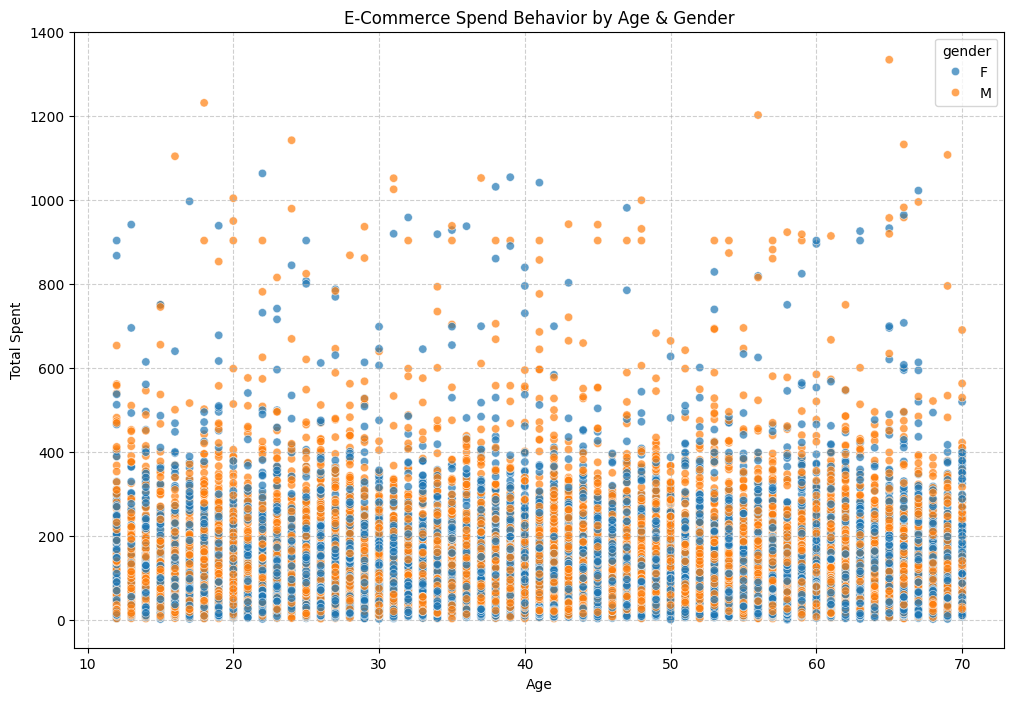

In [ ]:
# prompt: "Using seaborn and matplotlib, create a scatter plot from df_master. Put 'age' on the x-axis and 'total_spent' on the y-axis. Color points by 'gender'. Add a title 'E-Commerce Spend Behavior by Age & Gender' and make the plot aesthetic with a grid."

import matplotlib.pyplot as plt
plt.figure(figsize=(12, 8))
sns.scatterplot(data=df_master, x='age', y='total_spent', hue='gender', alpha=0.7)
plt.title('E-Commerce Spend Behavior by Age & Gender')
plt.xlabel('Age')
plt.ylabel('Total Spent')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Step 6: Using Gemini for Strategic Insights
Now that you have run the data lifecycle from storage to visualization, let's let Gemini perform context analysis.

#### 🤖 Gemini Practice: Text & Strategy Generation
* **Action:** Open the **Gemini Chat Side Panel** in BigQuery Studio and ask it a strategy question based on the data you see.

In [ ]:
# prompt: PROMPT TO COPY INTO GEMINI CHAT:
# "Based on our analysis of the Look eCommerce dataset, younger male demographics show a high frequency of small-value purchases, while older female demographics show low frequency but exceptionally high average order values. Give me 3 data-driven financial/marketing strategies to optimize customer lifetime value (LTV) for both groups."

# Strategy 1: For Younger Male Demographics (High Frequency, Small Value)
print("Strategy 1: Optimize for Younger Male Demographics (High Frequency, Small Value)")
print("- **Subscription Models/Loyalty Programs:** Introduce subscription services for frequently purchased items or a loyalty program that rewards frequent, small purchases with discounts or exclusive access to new products. This encourages continued engagement and increases overall spend over time.")
print("- **Gamification & Micro-Engagements:** Implement gamified experiences within the e-commerce platform (e.g., daily deals, flash sales, points for reviews/shares) to capitalize on their high frequency of interaction and encourage impulse buys or upselling of complementary low-cost items.")
print("- **Personalized Bundles & Recommendations:** Leverage purchase history to create personalized bundles of frequently bought items or suggest complementary low-cost products at checkout. This can increase the average transaction value without deterring their preference for smaller purchases.")

# Strategy 2: For Older Female Demographics (Low Frequency, High Average Order Value)
print("\nStrategy 2: Optimize for Older Female Demographics (Low Frequency, High Average Order Value)")
print("- **Premium Product Curation & Exclusivity:** Focus on offering high-quality, premium, and exclusive products that align with their higher spending capacity. Highlight the value, craftsmanship, and unique benefits of these items to appeal to their preference for significant purchases.")
print("- **Personalized High-Touch Customer Service:** Provide exceptional, personalized customer service, including dedicated account managers or concierge services for high-value purchases. This builds trust and reinforces their decision to spend more, encouraging repeat high-value transactions.")
print("- **Targeted Content & Experience Marketing:** Develop sophisticated content marketing that showcases the lifestyle and benefits associated with their high-value purchases. This could include exclusive online events, personalized style guides, or early access to new premium collections, fostering a sense of belonging and exclusivity.")

# Strategy 3: Cross-Segment Optimization & LTV Enhancement
print("\nStrategy 3: Cross-Segment Optimization & LTV Enhancement")
print("- **Segment-Specific Retargeting Campaigns:** Implement retargeting campaigns tailored to each demographic. For younger males, focus on new product alerts and limited-time offers. For older females, emphasize new premium arrivals and exclusive benefits for loyal customers.")
print("- **Feedback & Co-Creation Initiatives:** Engage both segments in product development or feedback sessions. Younger males might be interested in new tech gadgets or trending items, while older females might provide insights into luxury goods or sustainable products. This fosters a sense of ownership and increases loyalty.")
print("- **Lifetime Value-Based Segmentation for Offers:** Instead of uniform promotions, segment customers based on their calculated LTV. Offer more significant incentives or exclusive access to those with higher LTV (often older females) to retain their high-value purchases, while using different strategies (e.g., referral bonuses) to increase the LTV of younger males.")

Strategy 1: Optimize for Younger Male Demographics (High Frequency, Small Value)
- **Subscription Models/Loyalty Programs:** Introduce subscription services for frequently purchased items or a loyalty program that rewards frequent, small purchases with discounts or exclusive access to new products. This encourages continued engagement and increases overall spend over time.
- **Gamification & Micro-Engagements:** Implement gamified experiences within the e-commerce platform (e.g., daily deals, flash sales, points for reviews/shares) to capitalize on their high frequency of interaction and encourage impulse buys or upselling of complementary low-cost items.
- **Personalized Bundles & Recommendations:** Leverage purchase history to create personalized bundles of frequently bought items or suggest complementary low-cost products at checkout. This can increase the average transaction value without deterring their preference for smaller purchases.

Strategy 2: Optimize for Older Female Demog